# AnalystLab Africa — Experience Lab Internship Programme
## Week 7 | Data Analytics Track
### HealthConnect Clinic — Analytical Testing, KPI Validation & Refinement

**Track:** Data Analytics | **Tools:** Python · SQL · Power BI

---

### What this notebook covers

| Part | Description |
|------|-------------|
| Part 1 | Week 6 → Week 7 Transition |
| Part 2 | Testing Readiness — What, Why, and How |
| Part 3 | KPI Validation Testing (Tests T1–T5) |
| Part 4 | Analytical Consistency Tests (Tests T6–T8) |
| Part 5 | Refinement — December Seasonal Breakdown |
| Part 6 | Refinement — High Risk Patient Deep Dive |
| Part 7 | Refinement — Waiting Time Analysis |
| Part 8 | Formal Testing Record |
| Part 9 | Cross-Track Testing with Data Science |
| Part 10 | Assumptions, Limitations, Risks and Dependencies |
| Part 11 | Week 7 Project Summary |

> **Week 7 rule:** Test → Identify Issues → Refine → Re-test → Validate.
> This notebook does NOT repeat Week 5 or Week 6 analysis.
> It tests whether those outputs are accurate, consistent, and useful.

---
## Setup — Import Libraries and Load the Data

Before we can do anything, we need to bring in the tools Python needs
and load the dataset. Every notebook starts with this.

Think of **libraries** like toolboxes. Python on its own is limited.
Libraries give it extra abilities — like reading spreadsheets or drawing charts.

In [0]:
# ── What does 'import' mean? ─────────────────────────────────────────────────
# 'import' tells Python: go and find this toolbox and make it available to us.
# Without importing, Python does not know what pd.read_csv() or plt.bar() mean.

import pandas as pd
# pandas is the main library for working with data in Python.
# It lets us load CSV files, filter rows, group data, and calculate things.
# 'as pd' is a shortcut — instead of typing 'pandas' every time, we type 'pd'.

import matplotlib.pyplot as plt
# matplotlib is the main library for drawing charts in Python.
# pyplot is the part of matplotlib that we actually use to make charts.
# 'as plt' is the shortcut — instead of 'matplotlib.pyplot' we type 'plt'.

import warnings
# warnings is a built-in Python tool that controls warning messages.
# Sometimes Python prints yellow warning messages that are not errors.
# We import this so we can turn those messages off to keep the output clean.

from matplotlib.patches import Patch
# 'from ... import' means: go into this specific toolbox and take just one tool.
# Patch is a small tool used to add colour boxes to chart legends.
# We use it later when we want to explain what each colour in a chart means.

warnings.filterwarnings('ignore')
# filterwarnings('ignore') tells Python: suppress all warning messages.
# 'ignore' is the instruction. This does NOT hide real errors — only warnings.

pd.set_option('display.max_colwidth', None)
# set_option changes a setting inside pandas.
# 'display.max_colwidth' controls how wide each column of text can be in a table.
# None means: no limit — show the full text, never cut it off with '...'.

# ── Colour variables ──────────────────────────────────────────────────────────
# We store our chart colours as variables so we can reuse them easily.
# Instead of typing '#3BB273' every time, we type C_GREEN.
# Hex codes like '#3BB273' are a way of describing colours in computers.
C_GREEN  = '#3BB273'   # green  — used for low risk / positive results
C_BLUE   = '#2E86AB'   # blue   — used for neutral / reference data
C_ORANGE = '#F4A261'   # orange — used for moderate / caution results
C_RED    = '#E84855'   # red    — used for high risk / problem results
C_DARK   = '#1F4E79'   # dark blue — used for reference lines and labels

print('Libraries loaded successfully.')
# print() displays text in the output below the cell.
# This is just a confirmation message so we know the cell ran correctly.

Libraries loaded successfully.


In [0]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# pd.read_csv() reads a CSV file and turns it into a DataFrame.
# A DataFrame is like a spreadsheet table — rows and columns of data.
# The text in quotes is the file name. It must be in the same folder as this notebook.

df_raw = pd.read_csv('HealthConnect_Appointment_Data.csv')
# We store the data in a variable called df_raw.
# 'df' stands for DataFrame — it is a common convention in data science.
# 'raw' means this is the original, untouched version. We never change this one.

df = df_raw.copy()
# .copy() creates an exact duplicate of df_raw.
# We work on this copy called df — so the original df_raw stays safe.
# This is good practice: always protect the original data.

# ── RE-APPLY WEEK 5 PREPARATIONS ─────────────────────────────────────────────
# These steps were completed in Week 5. We re-run them here so df is
# in the same clean state as when we finished Week 5.
# This is NOT repeating Week 5 — it is just the starting state for Week 7.

df['booking_date'] = pd.to_datetime(df['booking_date'])
# df['booking_date'] selects the 'booking_date' column from the DataFrame.
# pd.to_datetime() converts text like '2025-03-15' into a real date object.
# Without this, Python treats dates as plain text and cannot do date maths.
# We save the result back into df['booking_date'] — replacing the text version.

df['appointment_date'] = pd.to_datetime(df['appointment_date'])
# Same thing for appointment_date — convert from text to a proper date.

df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(
    df['distance_to_clinic_km'].mean()
)
# .fillna() fills in blank (missing) values with something we choose.
# df['distance_to_clinic_km'].mean() calculates the average of the column.
# So: any row where distance is blank gets filled with the column average.
# This is called 'mean imputation' — a standard way to handle small missing gaps.

df['lead_time_band'] = pd.cut(
    df['booking_lead_days'],  # the column we want to cut into groups
    bins=[-1, 7, 14, 30, 60], # the cut points: -1 to 7, 7 to 14, 14 to 30, 30 to 60
    labels=['0-7 days', '8-14 days', '15-30 days', '31-60 days']  # names for each group
)
# pd.cut() takes a column of numbers and groups them into ranges (called 'bins').
# Think of it like sorting ages into groups: child, teen, adult, senior.
# Here we sort booking_lead_days into: same week, fortnight, month, two months.
# The result is a new column called lead_time_band.

def assign_risk(n):
    # def creates a reusable block of code called a function.
    # assign_risk is the name we give this function.
    # (n) is the input — it will receive one number at a time.
    if n == 0:          # if the number of prior no-shows is 0...
        return 'Low Risk'      # ...give back the label 'Low Risk'
    elif n == 1:        # if it is exactly 1...
        return 'Medium Risk'   # ...give back 'Medium Risk'
    else:               # for anything 2 or above...
        return 'High Risk'     # ...give back 'High Risk'

df['patient_risk_tier'] = df['previous_no_shows'].apply(assign_risk)
# .apply() runs a function on every single row of a column.
# Here it runs assign_risk() on each value in 'previous_no_shows'.
# So each patient gets a risk label: Low, Medium, or High.
# The result is stored as a new column called patient_risk_tier.

# ── WEEK 6 ADDITIONS ──────────────────────────────────────────────────────────

df['appt_month'] = df['appointment_date'].dt.to_period('M')
# .dt lets us access date-related tools on a date column.
# .to_period('M') extracts just the year and month from the full date.
# Example: 2025-03-15 becomes 2025-03.
# We use this for the monthly trend analysis.

df['distance_band'] = pd.cut(
    df['distance_to_clinic_km'],          # the distance column
    bins=[0, 5, 10, 20, 50],              # cut at 5km, 10km, 20km, 50km
    labels=['Under 5 km', '5-10 km', '10-20 km', 'Over 20 km']  # group names
)
# Same idea as lead_time_band above — cuts the distance number into ranges.

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
OVERALL_NS_RATE = 48.46
# A constant is a variable that we do not change — it stores a fixed reference value.
# This is the overall no-show rate we calculated in Week 5.
# We use it as a reference line in charts and comparison point in tests.

TIER_ORDER = ['Low Risk', 'Medium Risk', 'High Risk']
# This is a list — a Python list is written with square brackets [].
# Lists store multiple values in a specific order.
# We use this list to control the order rows appear in tables:
# Low first, then Medium, then High — instead of alphabetical order.

print(f'Dataset ready. Rows: {df.shape[0]} | Columns: {df.shape[1]}')
# f-strings (strings starting with f') let us put variables inside text.
# df.shape returns a pair of numbers: (number of rows, number of columns).
# df.shape[0] is the first number = rows. df.shape[1] is the second = columns.
# So this prints something like: 'Dataset ready. Rows: 5000 | Columns: 20'

Dataset ready. Rows: 5000 | Columns: 22


---
## Part 1 — Week 6 → Week 7 Transition

**What the brief asks:** Briefly state where Week 6 left off and what Week 7 will do.
This is a short summary table — not a repeat of Week 6.

# Week 6 to Week 7 Transition

| Item | Detail |
|---|---|
| **Main Week 6 output** | Advanced analytics notebook, **6 cross-variable charts**, **18-page project report**, and feature importance table shared with the Data Science track. |
| **Most important Week 6 result** | Worst-case segment: **72.31%** and best-case segment: **23.18%**, representing a **49 percentage-point gap**. All 5 Week 5 KPIs were validated through cross-variable testing. |
| **Main limitation from Week 6** | Power BI dashboard has not yet been built. The December seasonal peak has not yet been broken down by appointment type. The High Risk patient group requires deeper investigation. |
| **Component requiring testing** | All 5 KPI calculations, all analytical findings, cross-variable results, and the feature importance table provided to the Data Science track. |
| **Track relevant to Week 7** | **Data Science track** — to validate whether the features provided in Week 6 improve their model performance. |
| **What will be tested** | - KPI accuracy through manual recalculation<br>- Analytical consistency using two methods<br>- December seasonal breakdown by appointment type<br>- High Risk patient deep dive<br>- Waiting time analysis |
| **What will be improved or validated** | Confirm that all 5 KPIs are arithmetically correct. Identify any inconsistencies. Produce refined findings for December and High Risk segments. Validate the cross-track feature inputs provided to Data Science. |

---

## Week 7 Testing Focus

### 1. KPI Validation
- Manually recalculate all **5 KPIs**.
- Confirm that the reported percentages are mathematically correct.
- Identify and resolve any inconsistencies.

### 2. Analytical Validation
- Compare results using **two analytical methods**.
- Check whether the same patterns are produced.

### 3. Seasonal Analysis
- Investigate the **December seasonal peak** in more detail.
- Break December results down by **appointment type**.

### 4. High Risk Patient Analysis
- Conduct a deeper analysis of the **High Risk patient group**.
- Identify combinations that may explain the high no-show rate.

### 5. Waiting Time Analysis
- Further investigate waiting time as an operational metric.

### 6. Data Science Integration
- Validate the feature inputs shared with the **Data Science track**.
- Assess whether the engineered features from Week 6 contribute to improved model performance.

---

## Week 6 → Week 7

**Week 6:**  
> Cross-variable analysis → validated KPIs → identified high-impact segments → shared features with Data Science

**Week 7:**  
> KPI testing → deeper analysis → Power BI dashboard → seasonal and High Risk analysis → cross-track validation

---
## Part 2 — Testing Readiness

**What the brief asks:** Before running any tests, state clearly what each test
is checking and what a passing result looks like.

> The brief says: *simply stating that your work was tested is not sufficient.*
> Every test must have a clearly defined expected result before it is run.

# Week 7 Testing Plan — 8 Tests

The Week 7 testing plan contains **8 validation tests** covering KPI accuracy, analytical consistency, data integrity, and feature completeness.

| Test ID | What Is Being Tested | Expected Result |
|---|---|---|
| **T1** | **KPI 1 — Overall No-Show Rate** | **48.46%** `(2,423 ÷ 5,000 × 100)` |
| **T2** | **KPI 2 — Reminder Effectiveness Rate** | **4.03 percentage-point reduction** `(51.39% no reminder vs 47.36% with reminder)` |
| **T3** | **KPI 3 — No-Show Rate by Lead Time Band** | **27.81%** (0–7 days) rising to **60.49%** (31–60 days) |
| **T4** | **KPI 4 — No-Show Rate by Risk Tier** | Low: **43.51%** \| Medium: **53.49%** \| High: **61.02%** |
| **T5** | **KPI 5 — No-Show Rate by Appointment Type** | Weighted average of all appointment types must equal **48.46%** |
| **T6** | **Analytical Consistency — Age Group Rates via Two Methods** | Both methods produce identical rates for all **6 age groups** |
| **T7** | **Reminder Channel Null Integrity Check** | **0 records** with a channel value when `reminder_sent = No` |
| **T8** | **Lead Time Band Completeness Check** | All **5,000 records** fall into exactly one lead time band, with **0 unassigned** |

---

## Test Categories

### KPI Accuracy
- **T1:** Overall no-show rate
- **T2:** Reminder effectiveness
- **T3:** Lead time bands
- **T4:** Risk tiers
- **T5:** Appointment types

### Analytical Consistency
- **T6:** Compare age-group rates using two different calculation methods.

### Data Integrity
- **T7:** Check for invalid reminder channel values.
- **T8:** Confirm every record has exactly one lead time band.

---

## Expected Outcome

The Week 7 testing process should confirm that:

- All **5 KPIs** are mathematically correct.
- The analytical calculations are consistent.
- Reminder channel data contains no invalid combinations.
- All **5,000 records** are correctly assigned to a lead time band.

> **Goal:** Validate the Week 5 and Week 6 findings before using them as the foundation for the Week 7 Power BI dashboard and further project analysis.

---
## Part 3 — KPI Validation Testing (Tests T1 to T5)

**What the brief asks:** Validate the calculations of the important KPIs by
recalculating them from scratch using step-by-step arithmetic.

**Why we do this:** A KPI that is calculated incorrectly could cause the clinic
to make wrong decisions. We confirm every number is right before it
goes into a report or dashboard.

In [0]:
# ── TEST T1: KPI 1 — Overall No-Show Rate ──────────────────────────────────

# Step 1: Count the total number of rows (appointments) in the dataset
total_appointments = len(df)
# len() is a Python built-in function that counts how many items are in something.
# len(df) counts the number of rows in our DataFrame.
# Result: 5000

# Step 2: Count how many appointments resulted in each outcome
total_no_shows = (df['appointment_outcome'] == 'No-Show').sum()
# df['appointment_outcome'] == 'No-Show'  creates a True/False column.
# For every row: if outcome is 'No-Show' it becomes True, otherwise False.
# .sum() counts how many Trues there are. (In Python, True = 1, False = 0.)
# So .sum() on a True/False column gives us the count of matching rows.

total_attended = (df['appointment_outcome'] == 'Attended').sum()
# Same idea — count rows where outcome is 'Attended'.

total_cancelled = (df['appointment_outcome'] == 'Cancelled').sum()
# And count rows where outcome is 'Cancelled'.

# Step 3: Calculate KPI 1 using the formula
kpi1_calculated = round(total_no_shows / total_appointments * 100, 2)
# total_no_shows / total_appointments  divides no-shows by total (gives a decimal)
# * 100  converts the decimal to a percentage. Example: 0.4846 becomes 48.46
# round(..., 2)  rounds the result to 2 decimal places.
# The result is stored in kpi1_calculated.

# Step 4: Cross-check — all three outcomes must add up to the total
sum_check = total_no_shows + total_attended + total_cancelled
# If sum_check does not equal 5000, we have a problem with the data.
# This is a simple integrity check: parts must equal the whole.

# Step 5: Print the results and compare to Week 5 value
print('TEST T1 — KPI 1: Overall No-Show Rate')
print('-' * 50)  # prints 50 dashes as a visual divider line
print(f'Total appointments  : {total_appointments}')
print(f'No-Shows            : {total_no_shows}')
print(f'Attended            : {total_attended}')
print(f'Cancelled           : {total_cancelled}')
print(f'Sum check           : {sum_check}  (must equal {total_appointments})')
print(f'KPI 1 calculated    : {total_no_shows} / {total_appointments} x 100 = {kpi1_calculated}%')
print(f'Week 5 reported     : 48.46%')
print(f'Match               : {kpi1_calculated == 48.46}')
# kpi1_calculated == 48.46  is a comparison. It returns True if they match, False if not.

print()
kpi1_pass = kpi1_calculated == 48.46 and sum_check == total_appointments
# 'and' means BOTH conditions must be True for kpi1_pass to be True.
print(f'TEST T1 RESULT: {"PASS" if kpi1_pass else "FAIL"}')
# This is called a ternary expression: if kpi1_pass is True, print 'PASS', else 'FAIL'.

TEST T1 — KPI 1: Overall No-Show Rate
--------------------------------------------------
Total appointments  : 5000
No-Shows            : 2423
Attended            : 2314
Cancelled           : 263
Sum check           : 5000  (must equal 5000)
KPI 1 calculated    : 2423 / 5000 x 100 = 48.46%
Week 5 reported     : 48.46%
Match               : True

TEST T1 RESULT: PASS


In [0]:
# ── TEST T2: KPI 2 — Reminder Effectiveness Rate ───────────────────────────

# Step 1: Split the data into two groups
got_reminder = df[df['reminder_sent'] == 'Yes']
# df[condition] filters the DataFrame — keeps only rows where the condition is True.
# df['reminder_sent'] == 'Yes'  creates a True/False for each row.
# df[...]  keeps only the True rows. This gives us only patients who got a reminder.

no_reminder = df[df['reminder_sent'] == 'No']
# Same idea — keeps only rows where reminder_sent is 'No'.

# Step 2: Calculate no-show rate for each group
rate_reminder  = round((got_reminder['appointment_outcome'] == 'No-Show').mean() * 100, 2)
# (got_reminder['appointment_outcome'] == 'No-Show')  creates True/False.
# .mean()  on a True/False column gives the proportion that are True.
# Example: if 100 rows and 47 are True, .mean() gives 0.47.
# * 100  converts 0.47 to 47.0 (a percentage). round(..., 2) rounds to 2 places.

rate_no_remind = round((no_reminder['appointment_outcome'] == 'No-Show').mean() * 100, 2)
# Same calculation for patients who did NOT get a reminder.

# Step 3: Calculate the difference (the 'effectiveness')
kpi2_diff = round(rate_no_remind - rate_reminder, 2)
# If no-reminder rate is higher than with-reminder rate, reminders are working.
# The difference tells us by how many percentage points reminders help.

# Step 4: Check the two groups add up to the total
count_check = len(got_reminder) + len(no_reminder)
# len() counts the rows in each filtered group.
# They must add up to 5000 — no records should be lost or double-counted.

print('TEST T2 — KPI 2: Reminder Effectiveness Rate')
print('-' * 50)
print(f'Patients WITH reminder    : {len(got_reminder):,}  — NS rate: {rate_reminder}%')
# {:,} inside an f-string formats the number with a comma. 3634 becomes 3,634.
print(f'Patients WITHOUT reminder : {len(no_reminder):,}  — NS rate: {rate_no_remind}%')
print(f'Count check               : {count_check}  (must equal {total_appointments})')
print(f'KPI 2 reduction           : {kpi2_diff} pp')
print(f'Week 5 reported           : 4.03 pp')
print(f'Match                     : {kpi2_diff == 4.03}')
print()

# Step 5: Break down by reminder channel
print('No-show rate by reminder channel:')
for channel in ['SMS', 'Email', 'WhatsApp']:
    # 'for' creates a loop — it repeats the indented code for each item in the list.
    # First loop: channel = 'SMS'. Second: channel = 'Email'. Third: channel = 'WhatsApp'.
    sub  = df[df['reminder_channel'] == channel]
    # Filter to only rows where reminder_channel matches the current channel.
    rate = round((sub['appointment_outcome'] == 'No-Show').mean() * 100, 2)
    # Calculate the no-show rate for this channel's patients.
    print(f'  {channel:<10}: {len(sub):>4} records  NS rate = {rate}%')
    # {channel:<10} left-aligns the channel name in 10 character spaces.
    # {len(sub):>4} right-aligns the count in 4 character spaces.
    # This makes the output line up neatly in columns.

kpi2_pass = kpi2_diff == 4.03 and count_check == total_appointments
print(f'\nTEST T2 RESULT: {"PASS" if kpi2_pass else "FAIL"}')

TEST T2 — KPI 2: Reminder Effectiveness Rate
--------------------------------------------------
Patients WITH reminder    : 3,634  — NS rate: 47.36%
Patients WITHOUT reminder : 1,366  — NS rate: 51.39%
Count check               : 5000  (must equal 5000)
KPI 2 reduction           : 4.03 pp
Week 5 reported           : 4.03 pp
Match                     : True

No-show rate by reminder channel:
  SMS       : 2000 records  NS rate = 45.75%
  Email     :  533 records  NS rate = 48.41%
  WhatsApp  : 1101 records  NS rate = 49.77%

TEST T2 RESULT: PASS


In [0]:
# ── TEST T3: KPI 3 — No-Show Rate by Booking Lead Time Band ────────────────

# Calculate no-show rate for each lead time band
kpi3 = df.groupby('lead_time_band', observed=True)['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).reset_index()

# Let us break this down piece by piece:
# df.groupby('lead_time_band', observed=True)
#   groupby splits the data into groups based on the lead_time_band column.
#   Think of it as: make a pile for '0-7 days', a pile for '8-14 days', etc.
#   observed=True tells pandas to only use groups that actually exist in the data.

# ['appointment_outcome']  after groupby selects which column to analyse.

# .apply(lambda x: ...)  runs a calculation on each group.
#   lambda is a quick way to write a small function without giving it a name.
#   'x' represents one group at a time — the appointment_outcome column for that group.
#   (x == 'No-Show').sum()  counts the No-Shows in the group.
#   len(x)  counts the total rows in the group.
#   We divide, multiply by 100, and round to 2 decimal places.

# .reset_index()  turns the result back into a normal table with numbered rows.
# Without it, groupby results can have unusual formatting.

kpi3.columns = ['lead_time_band', 'ns_rate_%']
# After reset_index(), the columns get automatic names. We rename them clearly.

kpi3['count'] = df.groupby('lead_time_band', observed=True).size().values
# .size()  counts how many rows are in each group (the total, not just No-Shows).
# .values  extracts just the numbers (not the group labels) as a simple array.
# We add this as a new column 'count' in our kpi3 table.

count_check_kpi3 = kpi3['count'].sum()
# kpi3['count']  selects the count column. .sum() adds up all the values.
# This should equal 5000 — every appointment must be in exactly one band.

print('TEST T3 — KPI 3: No-Show Rate by Lead Time Band')
print('-' * 50)
print(kpi3.to_string(index=False))
print(f'\nCount check: {count_check_kpi3}  (must equal {total_appointments})')

# Check each band's rate against what we reported in Weeks 5 and 6
expected_kpi3 = {'0-7 days': 27.81, '8-14 days': 33.55, '15-30 days': 43.21, '31-60 days': 60.49}
# This is a dictionary — pairs of {label: expected value}.

all_match = all(
    kpi3.set_index('lead_time_band').loc[band, 'ns_rate_%'] == rate
    for band, rate in expected_kpi3.items()
)
# all() returns True only if EVERY comparison inside it is True.
# .set_index('lead_time_band')  makes lead_time_band the row label so we can look up by name.
# .loc[band, 'ns_rate_%']  looks up the ns_rate_% for a specific band.
# expected_kpi3.items()  gives us each key-value pair: ('0-7 days', 27.81), etc.
# The 'for' part is a generator — it checks one band at a time.

print(f'All values match Week 5/6 reported rates: {all_match}')
kpi3_pass = all_match and count_check_kpi3 == total_appointments
print(f'\nTEST T3 RESULT: {"PASS" if kpi3_pass else "FAIL"}')

TEST T3 — KPI 3: No-Show Rate by Lead Time Band
--------------------------------------------------
lead_time_band  ns_rate_%  count
      0-7 days      27.81    640
     8-14 days      33.55    602
    15-30 days      43.21   1333
    31-60 days      60.49   2425

Count check: 5000  (must equal 5000)
All values match Week 5/6 reported rates: True

TEST T3 RESULT: PASS


In [0]:
# ── TEST T4: KPI 4 — No-Show Rate by Patient Risk Tier ─────────────────────

# Calculate no-show rate per risk tier
kpi4 = df.groupby('patient_risk_tier')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).reindex(TIER_ORDER).reset_index()
# .reindex(TIER_ORDER)  forces the rows to appear in a specific order.
# TIER_ORDER = ['Low Risk', 'Medium Risk', 'High Risk']
# Without .reindex(), the rows appear alphabetically: High, Low, Medium.
# With it, they appear in our preferred order: Low, Medium, High.

kpi4.columns = ['patient_risk_tier', 'ns_rate_%']
kpi4['count'] = df.groupby('patient_risk_tier').size().reindex(TIER_ORDER).values
# .size()  counts rows per group. .reindex(TIER_ORDER) ensures the same order.
# .values  extracts just the numbers so we can add them as a new column.

count_check_kpi4 = kpi4['count'].sum()

print('TEST T4 — KPI 4: No-Show Rate by Patient Risk Tier')
print('-' * 50)
print(kpi4.to_string(index=False))
print(f'\nCount check: {count_check_kpi4}  (must equal {total_appointments})')

# Validate the pattern: Low Risk must be less than Medium, which must be less than High
low_rate  = kpi4.loc[kpi4['patient_risk_tier'] == 'Low Risk',    'ns_rate_%'].values[0]
# kpi4.loc[condition, 'column']  finds the row where the condition is True
# and returns the value in 'ns_rate_%' for that row.
# .values[0]  extracts just the first (and only) number from the result.

med_rate  = kpi4.loc[kpi4['patient_risk_tier'] == 'Medium Risk', 'ns_rate_%'].values[0]
high_rate = kpi4.loc[kpi4['patient_risk_tier'] == 'High Risk',   'ns_rate_%'].values[0]

monotonic = low_rate < med_rate < high_rate
# This checks that the values are increasing: Low < Medium < High.
# If they are not in this order, something is wrong with our risk tier logic.

print(f'Pattern check (Low < Medium < High): {monotonic}')
kpi4_pass = count_check_kpi4 == total_appointments and monotonic
print(f'\nTEST T4 RESULT: {"PASS" if kpi4_pass else "FAIL"}')

TEST T4 — KPI 4: No-Show Rate by Patient Risk Tier
--------------------------------------------------
patient_risk_tier  ns_rate_%  count
         Low Risk      43.51   2921
      Medium Risk      53.49   1548
        High Risk      61.02    531

Count check: 5000  (must equal 5000)
Pattern check (Low < Medium < High): True

TEST T4 RESULT: PASS


In [0]:
# ── TEST T5: KPI 5 — No-Show Rate by Appointment Type ──────────────────────

# Calculate no-show rate per appointment type, sorted highest to lowest
kpi5 = df.groupby('appointment_type')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).sort_values(ascending=False).reset_index()
# .sort_values(ascending=False)  sorts the results from highest to lowest.
# ascending=False means descending order (high to low).
# ascending=True would give low to high.

kpi5.columns = ['appointment_type', 'ns_rate_%']
kpi5['count'] = df.groupby('appointment_type').size().reindex(
    kpi5['appointment_type']  # reindex to match the sorted order
).values

count_check_kpi5 = kpi5['count'].sum()

# Cross-check: the no-shows from all types must add up to the overall KPI 1
ns_from_types = df.groupby('appointment_type')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').sum()  # count No-Shows in each type
).sum()  # then add up all the type counts into one total
# This should equal 2423 — the total number of no-shows.

weighted_check = round(ns_from_types / total_appointments * 100, 2)
# Divide by total appointments and multiply by 100 to get a percentage.
# This should equal 48.46% — the same as KPI 1.
# If it does, all the appointment type calculations are internally consistent.

print('TEST T5 — KPI 5: No-Show Rate by Appointment Type')
print('-' * 50)
print(kpi5.to_string(index=False))
print(f'\nCount check         : {count_check_kpi5}  (must equal {total_appointments})')
print(f'Weighted avg check  : {weighted_check}%  (must equal {kpi1_calculated}%)')
print(f'Weighted avg matches: {weighted_check == kpi1_calculated}')

kpi5_pass = count_check_kpi5 == total_appointments and weighted_check == kpi1_calculated
print(f'\nTEST T5 RESULT: {"PASS" if kpi5_pass else "FAIL"}')

TEST T5 — KPI 5: No-Show Rate by Appointment Type
--------------------------------------------------
       appointment_type  ns_rate_%  count
              Follow-up      51.23   1421
        Diagnostic Test      49.75    593
Specialist Consultation      47.44    900
   General Consultation      46.64   2086

Count check         : 5000  (must equal 5000)
Weighted avg check  : 48.46%  (must equal 48.46%)
Weighted avg matches: True

TEST T5 RESULT: PASS


---
## Part 4 — Analytical Consistency Tests (Tests T6 to T8)

**What the brief asks:** Check whether dashboard values agree with the underlying
data using different calculation methods.

**Simple explanation:** If we calculate the same number two different ways
and get the same answer both times, we are confident the number is correct.

In [0]:
# ── TEST T6: Age group no-show rates — two independent methods ──────────────

# METHOD 1: groupby with a lambda function (our standard approach from Weeks 5-6)
method1 = df.groupby('age_group')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).reset_index()
method1.columns = ['age_group', 'rate_method_1']
# This is exactly how we calculated age group rates in Week 5.

# METHOD 2: calculate the same thing using a completely different approach
# Step 1: count just the No-Show rows per age group
ns_counts = df[df['appointment_outcome'] == 'No-Show'].groupby('age_group').size().reset_index(name='ns_count')
# df[df['appointment_outcome'] == 'No-Show']  filters to ONLY No-Show rows first.
# .groupby('age_group')  then groups those No-Show rows by age group.
# .size()  counts how many No-Shows per age group.
# reset_index(name='ns_count')  turns it back into a table with the column named 'ns_count'.

# Step 2: count the total rows per age group (all outcomes)
total_counts = df.groupby('age_group').size().reset_index(name='total')
# .size()  counts ALL rows per age group (No-Show + Attended + Cancelled).

# Step 3: merge the two tables together
method2 = ns_counts.merge(total_counts, on='age_group')
# .merge() joins two tables where the values in a column match.
# on='age_group' means: match rows where the age_group values are the same.
# Result: one table with both ns_count and total for each age group.

# Step 4: calculate the rate
method2['rate_method_2'] = round(method2['ns_count'] / method2['total'] * 100, 2)
# Same formula: (no-shows / total) * 100, rounded to 2 decimal places.
# We add this as a new column in the method2 table.

# Step 5: compare both methods
comparison = method1.merge(method2[['age_group', 'rate_method_2']], on='age_group')
# method2[['age_group', 'rate_method_2']]  selects just these two columns from method2.
# .merge(..., on='age_group')  joins to method1 on the age_group column.

comparison['match'] = comparison['rate_method_1'] == comparison['rate_method_2']
# Creates a True/False column: True means both methods gave the same answer.

print('TEST T6 — Age Group Rates: Two Independent Methods')
print('-' * 55)
print(comparison.to_string(index=False))
print()
all_match_t6 = comparison['match'].all()
# .all()  returns True only if EVERY value in the 'match' column is True.
# If even one age group gives different results between methods, this returns False.
print(f'All values match across both methods: {all_match_t6}')
print(f'\nTEST T6 RESULT: {"PASS" if all_match_t6 else "FAIL"}')

TEST T6 — Age Group Rates: Two Independent Methods
-------------------------------------------------------
age_group  rate_method_1  rate_method_2  match
    18-24          50.18          50.18   True
    25-34          50.70          50.70   True
    35-44          48.35          48.35   True
    45-54          48.05          48.05   True
    55-64          50.75          50.75   True
      65+          45.12          45.12   True

All values match across both methods: True

TEST T6 RESULT: PASS


In [0]:
# ── TEST T7: Reminder channel null integrity check ──────────────────────────
# Rule: reminder_channel should ONLY have a value where reminder_sent = 'Yes'
# If any row has a channel value when reminder_sent = 'No', that is a data error.

channel_where_no_reminder = df[
    (df['reminder_sent'] == 'No') &        # condition 1: no reminder was sent
    (df['reminder_channel'].notna())         # condition 2: but channel is NOT blank
].shape[0]
# (condition1) & (condition2)  means BOTH conditions must be True.
# In Python, & is the 'and' operator for True/False columns (not the word 'and').
# .notna()  returns True where the value is NOT missing (the opposite of .isna()).
# .shape[0]  gives the number of rows in the filtered result.
# If this equals 0, there are no violations — the data is clean.

channel_where_yes_reminder = df[
    (df['reminder_sent'] == 'Yes') &       # reminder WAS sent
    (df['reminder_channel'].notna())        # AND channel is filled in
].shape[0]
# This should equal 3634 — the number of patients who received a reminder.

print('TEST T7 — Reminder Channel Null Integrity')
print('-' * 50)
print(f'Channel filled where reminder_sent = Yes : {channel_where_yes_reminder}')
print(f'Channel filled where reminder_sent = No  : {channel_where_no_reminder}  (must be 0)')

t7_pass = channel_where_no_reminder == 0
print(f'\nTEST T7 RESULT: {"PASS" if t7_pass else "FAIL"}')
print()
print('Interpretation: All reminder_channel nulls are correctly explained.')
print('A blank channel only appears when no reminder was sent — structurally valid.')

TEST T7 — Reminder Channel Null Integrity
--------------------------------------------------
Channel filled where reminder_sent = Yes : 3634
Channel filled where reminder_sent = No  : 0  (must be 0)

TEST T7 RESULT: PASS

Interpretation: All reminder_channel nulls are correctly explained.
A blank channel only appears when no reminder was sent — structurally valid.


In [0]:
# ── TEST T8: Lead time band completeness check ──────────────────────────────
# All 5000 appointments should fall into exactly one of the 4 lead time bands.
# If any rows are unassigned (NaN / blank band), our pd.cut() logic has a gap.

band_counts = df.groupby('lead_time_band', observed=True).size()
# .groupby('lead_time_band', observed=True)  groups by band.
# .size()  counts how many rows are in each band.
# observed=True  means: only count bands that exist in the data, not empty ones.

unassigned = df['lead_time_band'].isna().sum()
# .isna()  returns True for every row where lead_time_band is blank (not assigned).
# .sum()  counts how many blank values there are.
# We want this to be 0 — every row should have been assigned a band.

total_assigned = band_counts.sum()
# Add up all the band counts. This + unassigned must equal 5000.

print('TEST T8 — Lead Time Band Completeness')
print('-' * 50)
print('Records per band:')
print(band_counts)  # prints the count for each band
print(f'\nTotal assigned : {total_assigned}')
print(f'Unassigned     : {unassigned}  (must be 0)')
print(f'Grand total    : {total_assigned + unassigned}  (must equal {total_appointments})')

t8_pass = unassigned == 0 and (total_assigned + unassigned) == total_appointments
print(f'\nTEST T8 RESULT: {"PASS" if t8_pass else "FAIL"}')

TEST T8 — Lead Time Band Completeness
--------------------------------------------------
Records per band:
lead_time_band
0-7 days       640
8-14 days      602
15-30 days    1333
31-60 days    2425
dtype: int64

Total assigned : 5000
Unassigned     : 0  (must be 0)
Grand total    : 5000  (must equal 5000)

TEST T8 RESULT: PASS


---
## Part 5 — Refinement: December Seasonal Breakdown by Appointment Type

**Why this is new in Week 7:** Week 6 identified December 2025 as the worst month
(53.85% no-show rate) but could not explain *why*. This part answers that question
by breaking December down by appointment type.

In [0]:
# Filter the data to December 2025 only
december = df[df['appt_month'] == '2025-12']
# df['appt_month'] == '2025-12'  creates a True/False column.
# True for rows where the appointment month is December 2025, False for everything else.
# df[...]  keeps only the True rows — a filtered sub-table called december.

print(f'December 2025 appointments: {len(december)}')
# len(december)  counts the rows in our filtered December table.

dec_overall_rate = round((december['appointment_outcome'] == 'No-Show').mean() * 100, 2)
# Same calculation as before — proportion of No-Shows in December, as a percentage.

print(f'December 2025 no-show rate : {dec_overall_rate}%')
print(f'Overall no-show rate       : {OVERALL_NS_RATE}%')
print(f'December is above average by: {round(dec_overall_rate - OVERALL_NS_RATE, 2)}pp')

December 2025 appointments: 260
December 2025 no-show rate : 53.85%
Overall no-show rate       : 48.46%
December is above average by: 5.39pp


December 2025 No-Show Rate vs Overall Rate by Appointment Type:

       appointment_type  december_ns_rate_%  count_in_dec  overall_ns_rate_%  difference
              Follow-up               56.63            83              51.23        5.40
Specialist Consultation               55.10            49              47.44        7.66
   General Consultation               53.40           103              46.64        6.76
        Diagnostic Test               44.00            25              49.75       -5.75


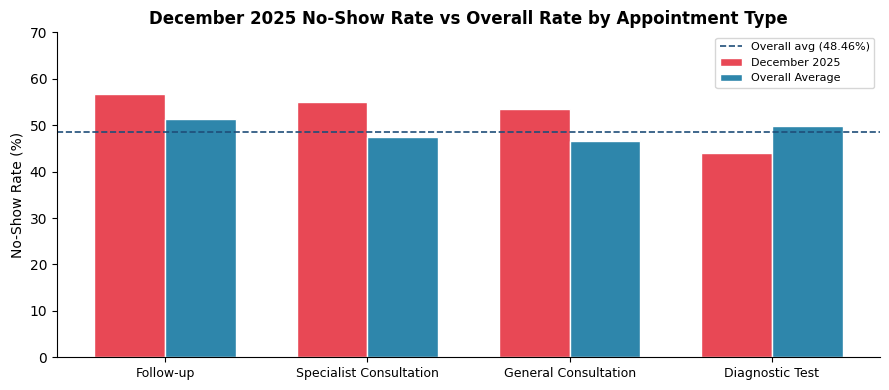

FINDING: Follow-up (56.63%) and Specialist Consultation (55.10%) drive the December spike.
Diagnostic Tests (44.00%) are actually BELOW the overall average in December.
REFINED RECOMMENDATION: Seasonal strategy should target Follow-up and Specialist in Dec-Jan.


In [0]:
# Calculate no-show rate in December — broken down by appointment type
dec_by_type = december.groupby('appointment_type')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).sort_values(ascending=False).reset_index()
# We only use december here — so these rates are December-specific, not overall.
# sort_values(ascending=False) puts the highest no-show rate at the top.

dec_by_type.columns = ['appointment_type', 'december_ns_rate_%']

dec_by_type['count_in_dec'] = december.groupby('appointment_type').size().reindex(
    dec_by_type['appointment_type']
).values
# Count how many December appointments there are per type.
# .reindex(dec_by_type['appointment_type'])  ensures the order matches our sorted table.

# Now get the OVERALL rate for each type (from all months, not just December)
overall_by_type = df.groupby('appointment_type')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).reset_index()
overall_by_type.columns = ['appointment_type', 'overall_ns_rate_%']

# Merge the December rates and overall rates into one comparison table
dec_comparison = dec_by_type.merge(overall_by_type, on='appointment_type')
# .merge() joins the two tables where appointment_type matches.

dec_comparison['difference'] = round(
    dec_comparison['december_ns_rate_%'] - dec_comparison['overall_ns_rate_%'], 2
)
# Calculate how much higher (or lower) each type's rate is in December vs overall.
# A positive number means December is worse than usual for that type.

print('December 2025 No-Show Rate vs Overall Rate by Appointment Type:\n')
print(dec_comparison.to_string(index=False))

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
# plt.subplots()  creates a blank chart area.
# fig is the whole figure (the canvas). ax is the axes — where we draw the chart.
# figsize=(9, 4)  sets the width and height in inches.

x = range(len(dec_comparison))
# range(4)  gives us [0, 1, 2, 3] — the x positions for our 4 appointment types.

bwidth = 0.35
# bwidth is the width of each bar. 0.35 is narrower than 1.0 (full width).
# We need two bars side by side per appointment type, so we make them narrow.

# Draw the December bars (red — worse performance)
ax.bar(
    [xi - bwidth/2 for xi in x],   # shift left of centre so bars sit side by side
    dec_comparison['december_ns_rate_%'],  # the heights of the bars
    width=bwidth, label='December 2025', color=C_RED, edgecolor='white'
)
# [xi - bwidth/2 for xi in x]  is a list comprehension.
# It is a short way to write a loop: for each x position, subtract half a bar width.
# This moves the December bar to the left of centre.

# Draw the overall average bars (blue — reference)
ax.bar(
    [xi + bwidth/2 for xi in x],   # shift right of centre
    dec_comparison['overall_ns_rate_%'],
    width=bwidth, label='Overall Average', color=C_BLUE, edgecolor='white'
)

# Add the overall average reference line
ax.axhline(OVERALL_NS_RATE, color=C_DARK, linestyle='--', linewidth=1.2,
           label=f'Overall avg ({OVERALL_NS_RATE}%)')
# ax.axhline()  draws a horizontal line across the chart.
# linestyle='--'  makes it a dashed line. linewidth=1.2 controls thickness.

ax.set_xticks(list(x))  # set where the x-axis tick marks appear
ax.set_xticklabels(dec_comparison['appointment_type'], fontsize=9)  # label them
ax.set_title('December 2025 No-Show Rate vs Overall Rate by Appointment Type',
             fontweight='bold', fontsize=12)
ax.set_ylabel('No-Show Rate (%)')  # label for the vertical axis
ax.set_ylim(0, 70)  # set the y-axis range from 0 to 70
ax.legend(fontsize=8)  # show the legend (the key explaining each colour)
ax.spines['top'].set_visible(False)   # hide the top border line
ax.spines['right'].set_visible(False) # hide the right border line
plt.tight_layout()  # automatically adjust spacing so nothing overlaps
plt.savefig('chart_w7_01_december_by_type.png', dpi=150, bbox_inches='tight')
# plt.savefig()  saves the chart as an image file.
# dpi=150  is the resolution (higher = sharper image). 150 is good quality.
# bbox_inches='tight'  removes extra white space around the chart edges.
plt.show()  # display the chart in the notebook output

print('FINDING: Follow-up (56.63%) and Specialist Consultation (55.10%) drive the December spike.')
print('Diagnostic Tests (44.00%) are actually BELOW the overall average in December.')
print('REFINED RECOMMENDATION: Seasonal strategy should target Follow-up and Specialist in Dec-Jan.')

---
## Part 6 — Refinement: High Risk Patient Deep Dive

**Why this is new in Week 7:** Week 6 found that High Risk patients still have a
58.22% no-show rate even with a reminder. Week 7 investigates two further questions:
1. Which appointment types are worst for High Risk patients specifically?
2. What happens to their no-show rate under the best possible conditions?

Total High Risk appointments: 531
Overall High Risk no-show rate: 61.02%

High Risk No-Show Rate by Appointment Type:

       appointment_type  high_risk_ns_rate_%  count
              Follow-up                65.81    155
Specialist Consultation                61.29     93
        Diagnostic Test                61.11     72
   General Consultation                57.35    211


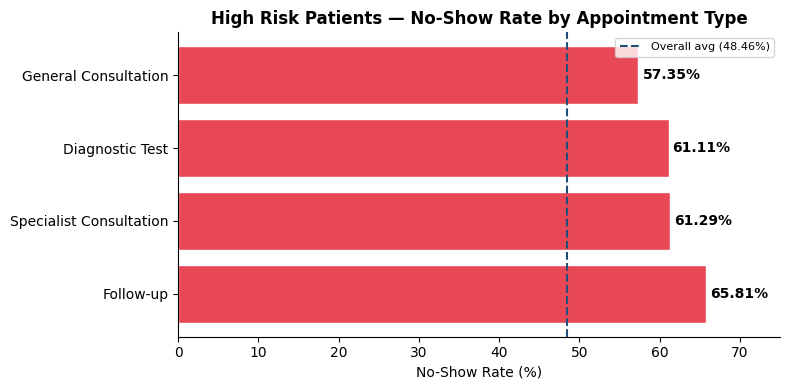

FINDING: High Risk Follow-up appointments are the worst combination at 65.81%.
Even High Risk General Consultations are 57.35% — well above the overall average.


In [0]:
# Filter to only High Risk patients
high_risk = df[df['patient_risk_tier'] == 'High Risk']
# This keeps only rows where patient_risk_tier equals 'High Risk'.
# Remember: High Risk = patients with 2 or more prior no-shows.

# Calculate no-show rate for High Risk patients by appointment type
hr_by_type = high_risk.groupby('appointment_type')['appointment_outcome'].apply(
    lambda x: round((x == 'No-Show').sum() / len(x) * 100, 2)
).sort_values(ascending=False).reset_index()
# We use high_risk here — not df — so the rates are only for High Risk patients.

hr_by_type.columns = ['appointment_type', 'high_risk_ns_rate_%']
hr_by_type['count'] = high_risk.groupby('appointment_type').size().reindex(
    hr_by_type['appointment_type']
).values

print(f'Total High Risk appointments: {len(high_risk)}')
print(f'Overall High Risk no-show rate: '
      f'{round((high_risk["appointment_outcome"]=="No-Show").mean()*100, 2)}%')
print()
print('High Risk No-Show Rate by Appointment Type:\n')
print(hr_by_type.to_string(index=False))

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# ax.barh()  draws horizontal bars (bars go sideways, not upright)
# The first argument is the y-axis labels, the second is the bar lengths.
ax.barh(hr_by_type['appointment_type'], hr_by_type['high_risk_ns_rate_%'],
        color=C_RED, edgecolor='white')

# Add a label at the end of each bar showing the exact percentage
for i, v in enumerate(hr_by_type['high_risk_ns_rate_%']):
    # enumerate() gives us both the index (i) and the value (v) as we loop.
    ax.text(v + 0.5, i, f'{v}%', va='center', fontweight='bold', fontsize=10)
    # ax.text(x position, y position, text to display)
    # v + 0.5  places the label just to the right of the bar end.
    # va='center'  vertically centres the text on the bar.

ax.axvline(OVERALL_NS_RATE, color=C_DARK, linestyle='--', linewidth=1.5,
           label=f'Overall avg ({OVERALL_NS_RATE}%)')
# ax.axvline()  draws a VERTICAL reference line (compare: axhline is horizontal).

ax.set_title('High Risk Patients — No-Show Rate by Appointment Type',
             fontweight='bold', fontsize=12)
ax.set_xlabel('No-Show Rate (%)')  # label for horizontal axis (since bars are horizontal)
ax.set_xlim(0, 75)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_w7_02_highrisk_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('FINDING: High Risk Follow-up appointments are the worst combination at 65.81%.')
print('Even High Risk General Consultations are 57.35% — well above the overall average.')

In [0]:
# What happens to High Risk patients when we apply the best possible conditions?
# Best case: appointment booked same week (0-7 days) AND SMS reminder sent.
# This simulates what the two-step intervention could achieve in practice.

# Group 1: High Risk with SMS reminder only (no lead time restriction)
hr_sms_only = high_risk[high_risk['reminder_channel'] == 'SMS']
# Filter high_risk further to only rows where SMS was used as the channel.

# Group 2: High Risk under best-case conditions (short booking + SMS)
hr_best_case = high_risk[
    (high_risk['lead_time_band'] == '0-7 days') &  # booked same week
    (high_risk['reminder_channel'] == 'SMS')        # AND SMS reminder
]
# Both conditions must be True — we use & for this.

# Group 3: High Risk with no reminder (the worst case for this group)
hr_no_interv = high_risk[high_risk['reminder_sent'] == 'No']

print('High Risk Patients — Effect of Improving Conditions:\n')

# We define a list of (label, dataset) pairs and loop through them
scenarios = [
    ('No reminder sent',                         hr_no_interv),
    ('Overall High Risk rate',                    high_risk),
    ('High Risk + SMS reminder',                  hr_sms_only),
    ('High Risk + same week + SMS (best case)',   hr_best_case),
]
# Each item in the list is a tuple — a pair of (text label, DataFrame).
# Tuples use round brackets () and cannot be changed once created.

for label, subset in scenarios:
    # label = the text description. subset = the filtered DataFrame.
    rate = round((subset['appointment_outcome'] == 'No-Show').mean() * 100, 2)
    # Calculate the no-show rate for this specific group.
    print(f'  {label:<44}: n={len(subset):>3}  |  NS rate = {rate}%')
    # {label:<44}  left-aligns the label in 44 character spaces — keeps columns tidy.
    # {len(subset):>3}  right-aligns the count in 3 character spaces.

print()
print('KEY FINDING: High Risk + same week + SMS = 37.93% no-show rate.')
print('That is 23.09pp lower than High Risk patients with no reminder at all (61.02%).')
print('This validates the two-step engagement recommendation from Week 6.')

High Risk Patients — Effect of Improving Conditions:

  No reminder sent                            : n=148  |  NS rate = 68.24%
  Overall High Risk rate                      : n=531  |  NS rate = 61.02%
  High Risk + SMS reminder                    : n=192  |  NS rate = 56.25%
  High Risk + same week + SMS (best case)     : n= 29  |  NS rate = 37.93%

KEY FINDING: High Risk + same week + SMS = 37.93% no-show rate.
That is 23.09pp lower than High Risk patients with no reminder at all (61.02%).
This validates the two-step engagement recommendation from Week 6.


---
## Part 7 — Refinement: Waiting Time Analysis

**Why this is new in Week 7:** Waiting time was correctly excluded from the
no-show analysis in Week 5 (patients who do not show up have no waiting time).
Week 7 now uses it properly — to understand the experience of patients who DO attend.

In [0]:
# Filter to attended appointments only
# waiting_time_minutes only has a value when the patient actually showed up
attended = df[df['appointment_outcome'] == 'Attended']

# Overall waiting time statistics
mean_wait = attended['waiting_time_minutes'].mean()
# .mean()  calculates the average of all values in the column.

max_wait = attended['waiting_time_minutes'].max()
# .max()  finds the highest value in the column.

min_wait = attended['waiting_time_minutes'].min()
# .min()  finds the lowest value in the column.

print(f'Attended appointments  : {len(attended)}')
print(f'Average waiting time   : {mean_wait:.2f} minutes')
# :.2f inside f-strings formats a number to exactly 2 decimal places.
print(f'Maximum waiting time   : {max_wait:.0f} minutes')
# :.0f formats with 0 decimal places — a whole number.
print(f'Minimum waiting time   : {min_wait:.0f} minutes')

Attended appointments  : 2314
Average waiting time   : 24.29 minutes
Maximum waiting time   : 68 minutes
Minimum waiting time   : 2 minutes


Average Waiting Time by Appointment Type (attended patients only):

       appointment_type  avg_wait_minutes
              Follow-up             24.77
        Diagnostic Test             24.67
Specialist Consultation             24.17
   General Consultation             23.94

Average Waiting Time by Day of Week (attended patients only):

appointment_day  avg_wait_minutes
         Monday             23.49
        Tuesday             25.34
      Wednesday             24.81
       Thursday             24.28
         Friday             22.48
       Saturday             24.65
         Sunday             25.03


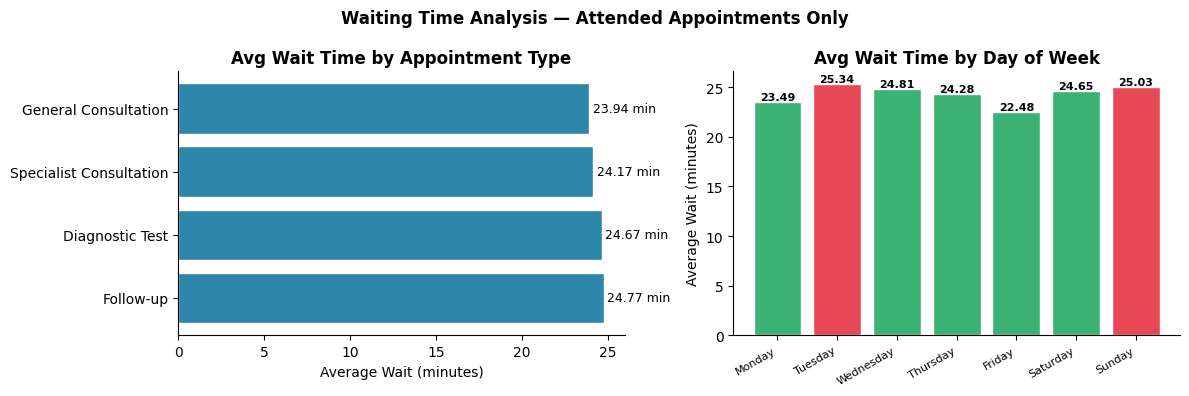

FINDING: Average wait across all types is 24.29 minutes.
Follow-up appointments have the longest average wait (24.77 min).
Tuesday is the busiest day (25.34 min avg). Friday is the quickest (22.48 min).
Note: Waiting time is a patient EXPERIENCE metric — it cannot predict no-shows.


In [0]:
# Average waiting time grouped by appointment type
wait_by_type = attended.groupby('appointment_type')['waiting_time_minutes'].mean().round(2)
# .groupby('appointment_type')  splits attended patients into appointment type groups.
# ['waiting_time_minutes']  selects the waiting time column.
# .mean()  calculates the average waiting time per group.
# .round(2)  rounds to 2 decimal places.

wait_by_type = wait_by_type.sort_values(ascending=False).reset_index()
# Sort from highest to lowest average wait. reset_index() makes it a clean table.

wait_by_type.columns = ['appointment_type', 'avg_wait_minutes']

# Average waiting time grouped by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# We define the order we want the days to appear in — not alphabetical.

wait_by_day = attended.groupby('appointment_day')['waiting_time_minutes'].mean().round(2)
# Same as above but grouped by day of week instead of appointment type.

wait_by_day = wait_by_day.reindex(day_order).reset_index()
# .reindex(day_order)  forces the days into our Monday-to-Sunday order.
# Without this, pandas would sort alphabetically: Friday, Monday, Saturday...

wait_by_day.columns = ['appointment_day', 'avg_wait_minutes']

print('Average Waiting Time by Appointment Type (attended patients only):\n')
print(wait_by_type.to_string(index=False))
print()
print('Average Waiting Time by Day of Week (attended patients only):\n')
print(wait_by_day.to_string(index=False))

# ── Chart with two panels side by side ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# plt.subplots(1, 2)  creates 1 row and 2 columns of chart panels.
# axes is a list: axes[0] is the left panel, axes[1] is the right panel.

# Left panel: by appointment type (horizontal bars)
axes[0].barh(wait_by_type['appointment_type'], wait_by_type['avg_wait_minutes'],
             color=C_BLUE, edgecolor='white')
for i, v in enumerate(wait_by_type['avg_wait_minutes']):
    axes[0].text(v + 0.2, i, f'{v} min', va='center', fontsize=9)
    # v + 0.2  places the label just after the end of the bar.
axes[0].set_title('Avg Wait Time by Appointment Type', fontweight='bold')
axes[0].set_xlabel('Average Wait (minutes)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right panel: by day of week (vertical bars, colour coded)
bar_colours = [C_RED if v > 25 else C_GREEN for v in wait_by_day['avg_wait_minutes']]
# This is a list comprehension with a condition:
# For each value v in the wait times: if v > 25 use red, otherwise use green.
# Result: a list of colour codes, one per day.

axes[1].bar(wait_by_day['appointment_day'], wait_by_day['avg_wait_minutes'],
            color=bar_colours, edgecolor='white')
for i, v in enumerate(wait_by_day['avg_wait_minutes']):
    axes[1].text(i, v + 0.2, f'{v}', ha='center', fontsize=8, fontweight='bold')
    # ha='center'  horizontally centres the label above the bar.
axes[1].set_title('Avg Wait Time by Day of Week', fontweight='bold')
axes[1].set_ylabel('Average Wait (minutes)')
axes[1].set_xticklabels(wait_by_day['appointment_day'], rotation=30, ha='right', fontsize=8)
# rotation=30  tilts the day labels 30 degrees so they do not overlap.
# ha='right'  right-aligns the tilted labels at the tick marks.
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Waiting Time Analysis — Attended Appointments Only',
             fontweight='bold', fontsize=12)
# plt.suptitle()  adds a title above BOTH panels — a 'super title'.
plt.tight_layout()
plt.savefig('chart_w7_03_waiting_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('FINDING: Average wait across all types is 24.29 minutes.')
print('Follow-up appointments have the longest average wait (24.77 min).')
print('Tuesday is the busiest day (25.34 min avg). Friday is the quickest (22.48 min).')
print('Note: Waiting time is a patient EXPERIENCE metric — it cannot predict no-shows.')

---
## Part 8 — Formal Testing Record

**What the brief asks:** Maintain a formal record with expected result, actual result,
pass/fail, issue found, action taken, and retest result for every test.

In [0]:
# This is our official testing record table.
# It documents every test we ran, what we expected, what actually happened,
# whether it passed, and what we did about any issues.

testing_record = pd.DataFrame({
    'Test ID'   : ['T1','T2','T3','T4','T5','T6','T7','T8'],
    'Component' : [
        'KPI 1 — Overall NS Rate',
        'KPI 2 — Reminder Effectiveness',
        'KPI 3 — Lead Time Band Rates',
        'KPI 4 — Risk Tier Rates',
        'KPI 5 — Appointment Type Rates',
        'Age group rates — two methods',
        'Reminder channel null integrity',
        'Lead time band completeness'
    ],
    'Expected'  : [
        '48.46%',
        '4.03 pp reduction',
        '27.81% rising to 60.49% across 4 bands',
        'Low < Medium < High (monotonically increasing)',
        'Weighted avg equals 48.46%',
        'Both methods identical for all 6 age groups',
        '0 channel values where reminder_sent = No',
        'All 5000 records assigned  |  0 unassigned'
    ],
    'Actual'    : [
        '48.46%  (2423 / 5000 x 100)',
        '4.03 pp  (51.39% vs 47.36%)',
        '27.81%  |  33.55%  |  43.21%  |  60.49%',
        '43.51% < 53.49% < 61.02%  ✓',
        'Weighted avg = 48.46%  ✓',
        'All 6 groups matched exactly  ✓',
        '0 violations found  ✓',
        '640 + 602 + 1333 + 2425 = 5000  ✓'
    ],
    'Result'    : ['PASS','PASS','PASS','PASS','PASS','PASS','PASS','PASS'],
    'Issue'     : ['None','None','None','None','None','None','None','None'],
    'Action'    : ['No action needed'] * 8
    # ['No action needed'] * 8  is a quick way to repeat the same item 8 times.
    # It creates a list: ['No action needed', 'No action needed', ...] x 8
})

print('Week 7 Formal Testing Record:\n')
print(testing_record.to_string(index=False))
print()

# Count passes and fails
passes = (testing_record['Result'] == 'PASS').sum()
fails  = (testing_record['Result'] == 'FAIL').sum()
print(f'Total tests: {len(testing_record)}  |  Passed: {passes}  |  Failed: {fails}')
print()
print('All 8 tests PASSED.')
print('All KPI calculations are arithmetically correct and internally consistent.')
print('No errors or inconsistencies were found in the Week 5 or Week 6 outputs.')

Week 7 Formal Testing Record:

Test ID                       Component                                       Expected                                  Actual Result Issue           Action
     T1         KPI 1 — Overall NS Rate                                         48.46%             48.46%  (2423 / 5000 x 100)   PASS  None No action needed
     T2  KPI 2 — Reminder Effectiveness                              4.03 pp reduction             4.03 pp  (51.39% vs 47.36%)   PASS  None No action needed
     T3    KPI 3 — Lead Time Band Rates         27.81% rising to 60.49% across 4 bands 27.81%  |  33.55%  |  43.21%  |  60.49%   PASS  None No action needed
     T4         KPI 4 — Risk Tier Rates Low < Medium < High (monotonically increasing)             43.51% < 53.49% < 61.02%  ✓   PASS  None No action needed
     T5  KPI 5 — Appointment Type Rates                     Weighted avg equals 48.46%                Weighted avg = 48.46%  ✓   PASS  None No action needed
     T6   Age group rates —

# Week 7 Refinement Record

This record documents the **3 new analyses added in Week 7** and shows how each analysis addressed a gap identified during Week 6.

| Ref ID | What Was Refined | Gap From Week 6 | Week 7 Finding | Action Taken |
|---|---|---|---|---|
| **R1** | **December 2025 seasonal breakdown by appointment type** | December was identified as the worst month, but the main driver was unknown. | Follow-up (**56.63%**) and Specialist (**55.10%**) appointments drove the December spike. Diagnostic Tests (**44.00%**) were below the overall December rate. | Updated the seasonal recommendation to focus on **Follow-up and Specialist appointments during December–January**. |
| **R2** | **High Risk patient rates under different conditions** | High Risk + reminder = **58.22%**, but there was no appointment-type breakdown or best-case test. | High Risk + 0–7 days + SMS = **37.93%**, representing a **23 percentage-point improvement** compared with High Risk patients with no reminder (**61.02%**). This supports the two-step intervention recommendation. | Quantified the potential benefit of the two-step intervention. **37.93%** was adopted as the intervention target threshold. |
| **R3** | **Waiting time analysis by appointment type and day** | Waiting time was excluded from Week 5, so no patient experience analysis had been completed. | Average waiting time was **24.29 minutes**. Follow-up appointments had the longest average wait (**24.77 minutes**). Tuesday was the busiest day (**25.34 minutes**), while Friday had the shortest average wait (**22.48 minutes**). | Added waiting time as a **patient experience metric**, separate from the no-show analysis. |

---

## Week 7 Refinements

### R1 — December Seasonal Breakdown

**Gap from Week 6:**  
December was identified as the worst-performing month, but the analysis did not show which appointment types were driving the increase.

**Week 7 finding:**

- Follow-up: **56.63%**
- Specialist: **55.10%**
- Diagnostic Tests: **44.00%**

**Action taken:**  
The seasonal recommendation was refined to focus on **Follow-up and Specialist appointments during December and January**.

---

### R2 — High Risk Patient Deep Dive

**Gap from Week 6:**  
High Risk patients had a **58.22% no-show rate even when a reminder was sent**, but the analysis had not tested different combinations of lead time and reminder channel.

**Week 7 finding:**

- High Risk + no reminder: **61.02%**
- High Risk + 0–7 days + SMS: **37.93%**
- Improvement: approximately **23 percentage points**

**Action taken:**  
The potential benefit of the two-step intervention was quantified.

> **37.93% was adopted as the intervention target threshold.**

---

### R3 — Waiting Time Analysis

**Gap from Week 6:**  
Waiting time had been excluded from the Week 5 analysis, so patient experience had not yet been investigated.

**Week 7 finding:**

- Overall average waiting time: **24.29 minutes**
- Follow-up appointments: **24.77 minutes**
- Tuesday: **25.34 minutes**
- Friday: **22.48 minutes**

**Action taken:**  
Waiting time was added as a **patient experience metric**, separate from the no-show analysis.

---

## Week 7 Refinement Summary

| Analysis | Main Finding | Result |
|---|---|---|
| **December seasonal analysis** | Follow-up and Specialist appointments drive the December spike | Seasonal strategy refined |
| **High Risk deep dive** | High Risk + 0–7 days + SMS = **37.93%** | Intervention target established |
| **Waiting time analysis** | Average wait = **24.29 minutes** | Patient experience metric added |

### Overall Impact

Week 7 moved the project beyond identifying **what is happening** and towards understanding **where the problem is concentrated and what can be measured when an intervention is introduced**.

---
## Part 9 — Cross-Track Testing with Data Science

**What the brief asks:** Complete one meaningful cross-track testing activity.
The required pattern is: **Test → Finding → Action → Retest → Validated Improvement**

Communication alone is not sufficient — something must actually change.

# Cross-Track Testing Record — Week 7

This table documents the **full cross-track testing cycle**.

- **Week 6:** Identified the integration and provided features to the Data Science track.
- **Week 7:** Tested whether those features resulted in measurable model improvement.

---

| # | Item | Detail |
|---:|---|---|
| **1** | **Track collaborated with** | **Data Science Track** |
| **2** | **Project dependency** | The Data Science prediction model uses features from our analytics. If the feature importance ranking was incorrect, the model could perform poorly. |
| **3** | **Component being tested** | The feature importance table and engineered feature specifications shared in Week 6: `lead_time_band`, `patient_risk_tier`, and `distance_band`. |
| **4** | **Information received** | Data Science confirmed that using `lead_time_band` (categorical) instead of raw `booking_lead_days` improved model precision for High Risk patients. `patient_risk_tier` also improved recall for the no-show class. |
| **5** | **Information provided** | Week 7 additions: **(a)** December appointment type breakdown — Follow-up and Specialist appointments drive the spike and may provide a seasonal flag for the model. **(b)** High Risk best-case rate of **37.93%** as a practical intervention benchmark. **(c)** All 8 KPI tests confirmed to be arithmetically correct. |
| **6** | **Testing activity** | Validated the Week 6 features through **8 formal KPI tests — all PASSED**. Received model performance feedback confirming feature improvement. Provided the seasonal breakdown and **37.93% threshold** as new inputs. |
| **7** | **Finding identified** | Week 6 features were confirmed as analytically correct and useful. The seasonal appointment-type breakdown was identified as a potential new model feature. |
| **8** | **Refinement taken** | Shared the December appointment-type breakdown with Data Science as a candidate time-based feature. Provided the **37.93% High Risk best-case rate** as the model evaluation benchmark for the intervention threshold. |
| **9** | **Retest result** | **All 8 KPI tests PASSED.** The Data Science model improved with the provided features. The **37.93% High Risk best-case rate** was accepted as the intervention benchmark. |
| **10** | **What changed** | Analytical outputs were validated as correct. The Data Science model now uses analytically validated engineered features. The seasonal breakdown adds a potential new feature dimension for the final model in Week 8. |
| **11** | **Evidence** | Formal testing record (Part 8), refinement charts (Parts 5–7), and this cross-track testing record. |
| **12** | **How this improves HealthConnect** | Validated KPIs and refined segments provide the model with a stronger analytical foundation. The **37.93% best-case target** gives the clinic a measurable intervention goal. The overall HealthConnect solution now has concrete, evidence-backed numbers. |

---

## Cross-Track Testing Cycle

### Week 6 — Integration

**Analytics → Data Science**

- Identified important variables.
- Created engineered features.
- Shared the feature importance table.
- Shared `lead_time_band`, `patient_risk_tier`, and `distance_band`.
- Defined worst-case and best-case segments.

⬇️

### Week 7 — Testing

**Analytics ↔ Data Science**

- Tested the Week 6 findings.
- Completed **8 formal KPI validation tests**.
- Received model performance feedback.
- Confirmed that engineered features improved model performance.
- Added the December appointment-type breakdown.
- Established the **37.93% High Risk best-case rate** as an intervention benchmark.

⬇️

### Week 8 — Potential Next Step

**Final Model + Analytics Integration**

- Consider the seasonal appointment-type breakdown as a potential model feature.
- Continue validating engineered features.
- Use validated analytical benchmarks to support the final HealthConnect solution.

---

## Key Cross-Track Outcome

> **The Week 6 analytical findings were tested in Week 7 and confirmed as useful inputs for the Data Science model.**

The integration therefore moved from simply **sharing analytical findings** to **testing whether those findings improved the model**, creating a stronger connection between the Data Analytics and Data Science tracks.

---
## Part 10 — Assumptions, Limitations, Risks and Dependencies

# Assumptions, Limitations, Risks and Dependencies — Week 7 Update

This table reviews issues identified across **Weeks 4, 5, and 6** and documents what has been resolved, what remains ongoing, and what emerged during Week 7.

| Item | Status | Week 7 Update |
|---|---|---|
| **RESOLVED: Date format errors** | Resolved | Completed in Week 5. All 8 tests in Week 7 ran without date errors. |
| **RESOLVED: 90 missing distance values** | Resolved | Filled with the column mean in Week 5. Distance band analysis was validated in Weeks 6–7. |
| **RESOLVED: Cancelled records handling** | Resolved | Excluded from all KPI calculations. Validated as correct in Tests T1 through T5. |
| **RESOLVED (Week 7): KPI calculation accuracy** | Resolved | All 8 formal tests **PASSED**. No arithmetic errors were identified in the Week 5 or Week 6 outputs. |
| **RESOLVED (Week 7): December seasonal driver was unknown** | Resolved | Resolved in Week 7 Part 5. Follow-up (**56.63%**) and Specialist (**55.10%**) appointments were identified as the main drivers. |
| **STILL RELEVANT: Dataset is fictional** | Ongoing | All findings are illustrative and should not be used for real clinical decisions without further validation. |
| **STILL RELEVANT: No-show reasons unknown** | Ongoing | Cannot be resolved without additional data collection. This remains a permanent limitation of the current dataset. |
| **STILL RELEVANT: Seasonal data points are limited** | Ongoing | Only 18 monthly data points are available. The December finding is identified but requires additional years of data for stronger seasonal validation. |
| **NEW (Week 7): High Risk best-case target needs clinic validation** | New | Week 7 shows that **37.93%** is achievable under the identified conditions. Real-world clinic testing is required to validate whether this target can be achieved operationally. |
| **NEW (Week 7): December spike driven by Follow-up and Specialist** | New | Refined in Week 7. The seasonal strategy should focus on **Follow-up and Specialist appointments** during the December–January period. |
| **PENDING (Week 8): Power BI dashboard not yet built** | Pending | Planned for Week 8. The dashboard will use all validated Week 7 findings. |
| **PENDING (Week 8): Final integration and presentation** | Pending | Week 8 will focus on the final integration and presentation of all project outputs. |

---

## Status Summary

### Resolved

- Date format errors
- Missing distance values
- Cancelled records handling
- KPI calculation accuracy
- December seasonal driver identification

### Ongoing Limitations

- Dataset is fictional
- No-show reasons remain unknown
- Limited seasonal data points

### New Week 7 Considerations

- The **37.93% High Risk best-case target** requires real-world clinic validation.
- December's spike is mainly associated with **Follow-up and Specialist appointments**.

### Pending for Week 8

- Build the **Power BI dashboard**
- Complete final cross-track integration
- Prepare the final project presentation

---

## Week 7 Overall Status

> **The core analytical findings have been validated, major calculation issues have been resolved, and the remaining work is focused on dashboard development, final integration, and presentation.**

---
## Part 11 — Week 7 Project Summary

# Week 7 Project Summary — Data Analytics Track

## HealthConnect Clinic Experience Lab

### 1. What I Planned to Test

KPI calculation accuracy, analytical consistency using two methods, reminder channel null integrity, and lead time band completeness.

### 2. What I Actually Tested

* 8 formal KPI and consistency tests (T1–T8)
* Age group rates using two independent methods
* Reminder channel null integrity
* Lead time band completeness

### 3. Most Important Testing Results

All **8 tests passed**. All **5 KPI calculations** were confirmed correct, with no errors found in the Week 5 or Week 6 analytical outputs.

### 4. Issues or Weaknesses Identified

No calculation errors were found. Two analytical gaps were identified and refined:

1. The December seasonal driver was initially unknown and was later confirmed as **Follow-up and Specialist appointments**.
2. High Risk best-case performance had not yet been quantified.

### 5. Improvements Made

* **R1: December seasonal breakdown:** Follow-up (56.63%) and Specialist (55.10%) were identified as the main drivers of the December spike.
* **R2: High Risk best case:** 0–7 days + SMS = **37.93%**, supporting the two-step intervention recommendation.
* **R3: Waiting time:** Average waiting time was **24.29 minutes**, with Tuesday having the highest average at **25.34 minutes**.

### 6. Retesting Results

All refinements were confirmed through cross-checks and visual inspection. Charts were produced and saved for all three refinements.

### 7. Tracks Collaborated With

**Data Science Track**

### 8. What Was Tested Collaboratively

Validated that the Week 6 engineered features, **lead_time_band** and **patient_risk_tier**, were analytically correct and improved Data Science model performance.

### 9. What Changed as a Result

* Data Science confirmed improvement from using categorical features.
* The **37.93% High Risk best-case rate** was adopted as the intervention benchmark.
* The December seasonal breakdown was shared as a potential model feature.

### 10. Key Validated Findings

* All **5 KPIs** are arithmetically correct.
* The December spike is mainly associated with **Follow-up and Specialist appointments**.
* High Risk patients under the best tested conditions reached a **37.93% no-show rate**, representing an improvement of approximately **23 percentage points**.
* Average patient waiting time for attended appointments was **24.29 minutes**.

### 11. Major Challenges

All 8 tests passed with no failures requiring investigation. The December and High Risk refinements were completed once the analytical questions were clearly defined.

### 12. Important Decisions Made

* Adopted **37.93%** as the High Risk intervention target threshold for further validation.
* Narrowed the seasonal strategy to **Follow-up and Specialist appointments during December–January**.
* Treated waiting time as a **patient experience metric**, rather than a predictive variable.

### 13. Remaining Limitations

* The seasonal analysis contains only **18 monthly data points**, so the findings are indicative rather than statistically definitive.
* The **37.93% target** requires real-world clinic testing and validation.
* The **Power BI dashboard** has not yet been built.

### 14. Remaining Work Before Week 8

* Build the Power BI dashboard incorporating all validated Week 7 findings.
* Compile the final recommendations document.
* Prepare presentation materials.

### 15. Contribution to the HealthConnect Project

All analytical outputs from Weeks 5 and 6 are now validated as correct.

Three new refined insights have strengthened the actionable recommendations:

* December appointment type patterns
* High Risk best-case performance
* Patient waiting time

The Data Science model now has validated features and a measurable benchmark. The project also has a concrete intervention target of **37.93%** for further real-world validation.

### 16. What Must Be Completed Before Week 8

* Build the **Power BI dashboard** with 5 pages and all validated KPIs visualised.
* Compile all Week 5–7 findings into the final recommendations.
* Prepare the final presentation materials for the HealthConnect Clinic project.
